# DL 3D ML Final Selection

Configurable final-selection notebook for dl_3d_ml_cv and dl_3d_ml_all.


In [1]:
# ============================================================
# 1. Imports
# ============================================================

import os
import json
import itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix


In [2]:
# ============================================================
# 2. Settings
# ============================================================

TASK = "Prognosis"
LABEL_COL = "Prognosis_label"

model_root = "/host/d/projects/Habitats/models"

# Choose one DL-to-ML output branch here:
#   "cv"  -> /models/{TASK}/dl_3d_ml_cv
#   "all" -> /models/{TASK}/dl_3d_ml_all
# Direct folder names such as "dl_3d_ml_cv" also work.
DL_TRAINING_MODE = "all"

dl_mode_map = {
    "cv": "dl_3d_ml_cv",
    "_cv": "dl_3d_ml_cv",
    "dl_3d_ml_cv": "dl_3d_ml_cv",
    "all": "dl_3d_ml_all",
    "_all": "dl_3d_ml_all",
    "dl_3d_ml_all": "dl_3d_ml_all",
}
if DL_TRAINING_MODE not in dl_mode_map:
    raise ValueError(f"Unknown DL_TRAINING_MODE={DL_TRAINING_MODE}. Options: {sorted(dl_mode_map)}")

IMAGE_TYPE = dl_mode_map[DL_TRAINING_MODE]
DISPLAY_NAME = IMAGE_TYPE
model_output_root = os.path.join(model_root, TASK, IMAGE_TYPE)
final_selection_out_dir = os.path.join(model_output_root, "final_selections")
os.makedirs(final_selection_out_dir, exist_ok=True)

selected_cv_experiments = [
    {"classifier": "LR", "experiment": "random20_lasso_top6"},
]

selected_internal_test_experiments = [
    {"classifier": "LR", "experiment": "random0_lasso_top6"},
    {"classifier": "XGBoost", "experiment": "random0_rfe_top10"},
]
selected_external_test_experiments = [
    {"classifier": "LR", "experiment": "random40_lasso_top6"},
]

# For CV, choose which probability column to read from each selected setting.
# Options: "cv", "allotherdata", "final", "advanced".
CV_PROBABILITY_MODE = "final"

# For internal/external test, choose which probability column to read from each selected setting.
# Options: "final", "mean", "alldata", "best".
# The final-selection output filenames remain unchanged regardless of these choices.
INTERNAL_TEST_PROBABILITY_MODE = "final"
EXTERNAL_TEST_PROBABILITY_MODE = "final"

print("DL training mode:", DL_TRAINING_MODE)
print("Model output root:", model_output_root)
print("Final selection output:", final_selection_out_dir)
print("CV probability mode:", CV_PROBABILITY_MODE)
print("CV selected settings:", selected_cv_experiments)
print("Internal-test probability mode:", INTERNAL_TEST_PROBABILITY_MODE)
print("Internal-test selected settings:", selected_internal_test_experiments)
print("External-test probability mode:", EXTERNAL_TEST_PROBABILITY_MODE)
print("External-test selected settings:", selected_external_test_experiments)


DL training mode: all
Model output root: /host/d/projects/Habitats/models/Prognosis/dl_3d_ml_all
Final selection output: /host/d/projects/Habitats/models/Prognosis/dl_3d_ml_all/final_selections
CV probability mode: final
CV selected settings: [{'classifier': 'LR', 'experiment': 'random20_lasso_top6'}]
Internal-test probability mode: final
Internal-test selected settings: [{'classifier': 'LR', 'experiment': 'random0_lasso_top6'}, {'classifier': 'XGBoost', 'experiment': 'random0_rfe_top10'}]
External-test probability mode: final
External-test selected settings: [{'classifier': 'LR', 'experiment': 'random40_lasso_top6'}]


In [3]:
# ============================================================
# 3. Helper functions
# ============================================================

ID_COLS = ["Patient_set", "Patient_index"]
BASE_KEYS = ID_COLS + [LABEL_COL]
OPTIONAL_CONTEXT_COLS = ["Image_filepath", "Mask_filepath", "split", "fold"]


def context_columns(df):
    return [c for c in OPTIONAL_CONTEXT_COLS if c in df.columns]


def merge_on_keys(tables):
    if len(tables) == 0:
        raise RuntimeError("No tables to merge.")
    merged = tables[0].copy()
    for table in tables[1:]:
        drop_cols = [c for c in context_columns(table) if c in merged.columns]
        table2 = table.drop(columns=drop_cols)
        merged = merged.merge(table2, on=BASE_KEYS, how="inner")
    return merged



def setting_tag(item):
    return f"{item['classifier']}__{item['experiment']}"


def setting_dir(item):
    return os.path.join(model_output_root, item["classifier"], item["experiment"])


def load_summary_json(item):
    summary_path = os.path.join(setting_dir(item), "summary.json")
    if not os.path.isfile(summary_path):
        return {}, summary_path
    with open(summary_path, "r") as f:
        return json.load(f), summary_path


def read_excel_required(path):
    if not os.path.isfile(path):
        raise FileNotFoundError(path)
    return pd.read_excel(path)


def safe_auc(y_true, y_prob):
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob).astype(float)
    if len(np.unique(y_true)) < 2:
        return np.nan
    return float(roc_auc_score(y_true, y_prob))


def bootstrap_auc_ci(y_true, y_prob, n_bootstrap=2000, random_state=0):
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob).astype(float)
    if len(np.unique(y_true)) < 2:
        return np.nan, np.nan

    rng = np.random.default_rng(random_state)
    aucs = []
    n = len(y_true)
    for _ in range(n_bootstrap):
        idx = rng.integers(0, n, n)
        if len(np.unique(y_true[idx])) < 2:
            continue
        aucs.append(roc_auc_score(y_true[idx], y_prob[idx]))
    if len(aucs) == 0:
        return np.nan, np.nan
    return float(np.percentile(aucs, 2.5)), float(np.percentile(aucs, 97.5))


def best_threshold_by_youden(y_true, y_prob):
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob).astype(float)
    if len(np.unique(y_true)) < 2:
        return 0.5
    fpr, tpr, thresholds = roc_curve(y_true, y_prob)
    youden = tpr - fpr
    return float(thresholds[int(np.argmax(youden))])


def evaluate_probability(y_true, y_prob, prefix=""):
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob).astype(float)

    auc = safe_auc(y_true, y_prob)
    auc_ci_low, auc_ci_high = bootstrap_auc_ci(y_true, y_prob)
    threshold = best_threshold_by_youden(y_true, y_prob)
    y_pred = (y_prob >= threshold).astype(int)

    if len(np.unique(y_true)) == 2:
        tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
        accuracy = (tp + tn) / max(tp + tn + fp + fn, 1)
        sensitivity = tp / max(tp + fn, 1)
        specificity = tn / max(tn + fp, 1)
    else:
        accuracy = sensitivity = specificity = np.nan

    return {
        f"{prefix}auc": auc,
        f"{prefix}auc_ci_low": auc_ci_low,
        f"{prefix}auc_ci_high": auc_ci_high,
        f"{prefix}threshold": threshold,
        f"{prefix}accuracy": float(accuracy),
        f"{prefix}sensitivity": float(sensitivity),
        f"{prefix}specificity": float(specificity),
        f"{prefix}n": int(len(y_true)),
        f"{prefix}positive_fraction": float(np.mean(y_true)) if len(y_true) else np.nan,
    }


def resolve_cv_probability_column(df, summary, explicit_col=None):
    if explicit_col is not None:
        if explicit_col not in df.columns:
            raise KeyError(f"Requested probability_col={explicit_col} not found. Available: {df.columns.tolist()}")
        return explicit_col, "manual"

    # Choose which CV probability from each selected setting should enter final selection.
    # Options: "cv", "allotherdata", "final", "advanced".
    probability_mode = str(CV_PROBABILITY_MODE).lower()
    mode_to_col = {
        "cv": "prob_cv",
        "traditional": "prob_cv",
        "together": "prob_cv",
        "allotherdata": "prob_cv_allotherdata",
        "all_other_data": "prob_cv_allotherdata",
        "final": "prob_cv_final",
        "advanced": "prob_cv_final_advanced",
        "final_advanced": "prob_cv_final_advanced",
    }
    if probability_mode not in mode_to_col:
        raise ValueError(
            f"Unknown CV_PROBABILITY_MODE={CV_PROBABILITY_MODE}. "
            f"Choose from {sorted(mode_to_col.keys())}."
        )

    prob_col = mode_to_col[probability_mode]
    if prob_col in df.columns:
        return prob_col, f"mode:{probability_mode}"

    # Fallback for older files where the selected ordinary final method is only in summary.json.
    if probability_mode == "final":
        method = str(summary.get("cv_final_selected_method", "")).lower()
        method_to_col = {
            "together": "prob_cv",
            "cv": "prob_cv",
            "allotherdata": "prob_cv_allotherdata",
            "all_other_data": "prob_cv_allotherdata",
        }
        if method in method_to_col and method_to_col[method] in df.columns:
            return method_to_col[method], f"summary:{method}"

    raise KeyError(
        f"Requested CV_PROBABILITY_MODE={CV_PROBABILITY_MODE}, but {prob_col} was not found. "
        f"Available columns: {df.columns.tolist()}"
    )

def get_holdout_probability_mode(dataset_name):
    if dataset_name == "internal_test":
        return INTERNAL_TEST_PROBABILITY_MODE
    if dataset_name == "external_test":
        return EXTERNAL_TEST_PROBABILITY_MODE
    raise ValueError(f"Unknown holdout dataset_name: {dataset_name}")


def resolve_test_probability_column(df, explicit_col=None, probability_mode="final"):
    if explicit_col is not None:
        if explicit_col not in df.columns:
            raise KeyError(f"Requested probability_col={explicit_col} not found. Available: {df.columns.tolist()}")
        return explicit_col, "manual"

    probability_mode = str(probability_mode).lower()
    mode_to_col = {
        "final": "prob_final",
        "mean": "prob_mean",
        "alldata": "prob_alldata",
        "all": "prob_alldata",
        "all_data": "prob_alldata",
        "best": "prob_best",
    }
    if probability_mode not in mode_to_col:
        raise ValueError(
            f"Unknown probability_mode={probability_mode}. "
            f"Choose from {sorted(mode_to_col.keys())}."
        )

    prob_col = mode_to_col[probability_mode]
    if prob_col not in df.columns:
        raise KeyError(
            f"Requested probability_mode={probability_mode}, but {prob_col} was not found. "
            f"Available columns: {df.columns.tolist()}"
        )

    return prob_col, f"mode:{probability_mode}"

def read_cv_prediction(item):
    tag = setting_tag(item)
    exp_dir = setting_dir(item)
    pred_path = os.path.join(exp_dir, "cv_predictions.xlsx")
    df = read_excel_required(pred_path)
    summary, summary_path = load_summary_json(item)
    prob_col, prob_source = resolve_cv_probability_column(df, summary, item.get("probability_col"))

    keep_cols = BASE_KEYS + context_columns(df)
    if "cv_final_advanced_selected_method" in df.columns:
        keep_cols += ["cv_final_advanced_selected_method"]

    out = df[keep_cols].copy()
    out[f"prob_cv_final_{tag}"] = df[prob_col].astype(float)
    if "fold" in df.columns:
        out[f"fold_{tag}"] = df["fold"].astype(int)
    if "cv_final_advanced_selected_method" in out.columns:
        out = out.rename(columns={"cv_final_advanced_selected_method": f"cv_final_advanced_selected_method_{tag}"})

    info = {
        "tag": tag,
        "classifier": item["classifier"],
        "experiment": item["experiment"],
        "experiment_dir": exp_dir,
        "prediction_path": pred_path,
        "summary_path": summary_path,
        "probability_column": prob_col,
        "probability_source": prob_source,
    }
    return out, info


def read_train_prediction(item):
    tag = setting_tag(item)
    exp_dir = setting_dir(item)
    pred_path = os.path.join(exp_dir, "train_predictions.xlsx")
    df = read_excel_required(pred_path)
    if "prob_train" not in df.columns:
        raise KeyError(f"prob_train not found in {pred_path}")

    keep_cols = BASE_KEYS + context_columns(df)
    out = df[keep_cols].copy()
    out[f"prob_train_{tag}"] = df["prob_train"].astype(float)

    metrics_path = os.path.join(exp_dir, "train_metrics.xlsx")
    info = {
        "tag": tag,
        "classifier": item["classifier"],
        "experiment": item["experiment"],
        "experiment_dir": exp_dir,
        "prediction_path": pred_path,
        "metrics_path": metrics_path,
    }
    return out, info


def read_holdout_prediction(item, dataset_name, filename):
    tag = setting_tag(item)
    exp_dir = setting_dir(item)
    pred_path = os.path.join(exp_dir, filename)
    df = read_excel_required(pred_path)
    probability_mode = get_holdout_probability_mode(dataset_name)
    prob_col, prob_source = resolve_test_probability_column(
        df,
        explicit_col=item.get("probability_col"),
        probability_mode=probability_mode,
    )

    keep_cols = BASE_KEYS + context_columns(df)
    for extra in ["final_selected_method", "best_model_fold"]:
        if extra in df.columns:
            keep_cols.append(extra)

    selected_probability_col = f"prob_{probability_mode}_{dataset_name}_{tag}"
    out = df[keep_cols].copy()
    out[selected_probability_col] = df[prob_col].astype(float)
    rename_map = {}
    for extra in ["final_selected_method", "best_model_fold"]:
        if extra in out.columns:
            rename_map[extra] = f"{dataset_name}_{extra}_{tag}"
    out = out.rename(columns=rename_map)

    info = {
        "tag": tag,
        "classifier": item["classifier"],
        "experiment": item["experiment"],
        "experiment_dir": exp_dir,
        "prediction_path": pred_path,
        "probability_mode": probability_mode,
        "selected_probability_column": selected_probability_col,
        "probability_column": prob_col,
        "probability_source": prob_source,
    }
    return out, info

def search_best_fold_mix(df, prob_cols, fold_col):
    if fold_col not in df.columns:
        raise KeyError(f"Reference fold column not found: {fold_col}")

    y_true = df[LABEL_COL].astype(int).to_numpy()
    folds = sorted(df[fold_col].dropna().astype(int).unique().tolist())
    best_auc = -np.inf
    best_combo = None
    best_prob = None
    combo_count = 0

    for combo in itertools.product(prob_cols, repeat=len(folds)):
        combo_count += 1
        prob = np.zeros(len(df), dtype=float)
        for fold_value, selected_col in zip(folds, combo):
            mask = df[fold_col].astype(int).to_numpy() == int(fold_value)
            prob[mask] = df.loc[mask, selected_col].astype(float).to_numpy()
        auc = safe_auc(y_true, prob)
        if np.isnan(auc):
            continue
        if auc > best_auc:
            best_auc = auc
            best_combo = dict(zip(folds, combo))
            best_prob = prob.copy()

    if best_combo is None:
        raise RuntimeError("No valid fold mix could be evaluated.")

    mix_df = pd.DataFrame({
        "fold": list(best_combo.keys()),
        "selected_probability_column": list(best_combo.values()),
    })
    return best_prob, mix_df, combo_count


def search_best_holdout_mix(df, prob_cols):
    """Find the best holdout experiment subset by AUC.

    CV mix can choose a different experiment for each fold. Holdout sets do not
    have validation folds, so the analogous overfitted final-selection search is:
    evaluate every non-empty subset of selected experiments, average the subset
    probabilities, and keep the subset with the highest holdout AUC.
    """
    if len(prob_cols) == 0:
        raise ValueError("prob_cols is empty.")

    y_true = df[LABEL_COL].astype(int).to_numpy()
    best_auc = -np.inf
    best_combo = None
    best_prob = None
    combo_count = 0

    for subset_size in range(1, len(prob_cols) + 1):
        for combo in itertools.combinations(prob_cols, subset_size):
            combo_count += 1
            prob = df.loc[:, list(combo)].astype(float).mean(axis=1).to_numpy()
            auc = safe_auc(y_true, prob)
            if np.isnan(auc):
                continue
            if auc > best_auc:
                best_auc = auc
                best_combo = tuple(combo)
                best_prob = prob.copy()

    if best_combo is None:
        raise RuntimeError("No valid holdout mix could be evaluated.")

    mix_df = pd.DataFrame({
        "subset_size": [len(best_combo)],
        "selected_probability_columns": [";".join(best_combo)],
        "auc": [best_auc],
        "combo_count": [combo_count],
    })
    return best_prob, mix_df, combo_count


def plot_roc_curves(y_true, curve_specs, title, save_path):
    plt.figure(figsize=(6, 6))
    for label, y_prob in curve_specs:
        auc = safe_auc(y_true, y_prob)
        fpr, tpr, _ = roc_curve(y_true, y_prob)
        plt.plot(fpr, tpr, linewidth=2, label=f"{label} AUC={auc:.3f}")
    plt.plot([0, 1], [0, 1], "k--", linewidth=1)
    plt.xlabel("False positive rate")
    plt.ylabel("True positive rate")
    plt.title(title)
    plt.legend(loc="lower right")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(save_path)
    plt.show()
    print("Saved ROC:", save_path)


Loaded CV: LR__random20_lasso_top6 probability column: prob_cv
CV mean AUC: 0.8442225811187785
CV mix AUC : 0.8442225811187785
CV final_selection selected method: mean


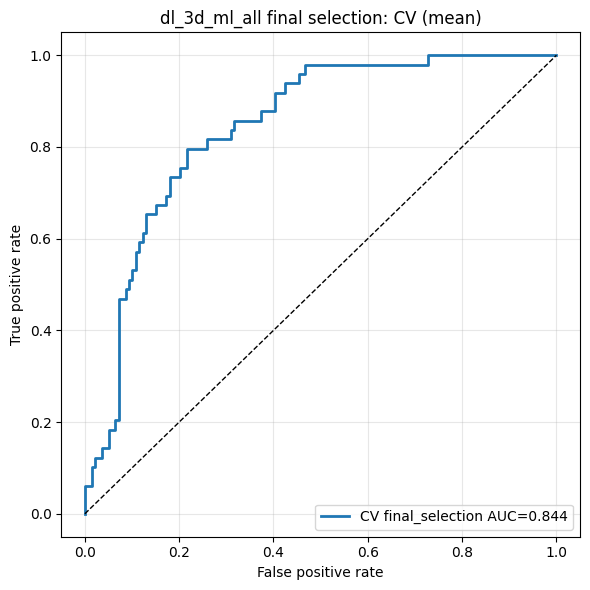

Saved ROC: /host/d/projects/Habitats/models/Prognosis/dl_3d_ml_all/final_selections/ROC_curve_cv_final_selection.pdf
Saved CV final-selection predictions: /host/d/projects/Habitats/models/Prognosis/dl_3d_ml_all/final_selections/cv_final_selection_predictions.xlsx
Saved CV final-selection metrics: /host/d/projects/Habitats/models/Prognosis/dl_3d_ml_all/final_selections/cv_final_selection_metrics.xlsx
Saved CV best mix: /host/d/projects/Habitats/models/Prognosis/dl_3d_ml_all/final_selections/cv_final_selection_best_mix.xlsx
Saved CV final-selection manifest: /host/d/projects/Habitats/models/Prognosis/dl_3d_ml_all/final_selections/cv_final_selection_manifest.json


,dataset,fusion_method,setting_tag,probability_column,is_final_selection,auc,auc_ci_low,auc_ci_high,threshold,accuracy,sensitivity,specificity,n,positive_fraction,final_selection_selected_method,source_probability_column
0,cv,single_setting,LR__random20_lasso_top6,prob_cv_final_LR__random20_lasso_top6,False,0.844223,0.784198,0.899814,0.482431,0.787234,0.795918,0.784173,188,0.260638,NaN,NaN
1,cv,mean,selected_settings,prob_mean,True,0.844223,0.784198,0.899814,0.482431,0.787234,0.795918,0.784173,188,0.260638,NaN,NaN
2,cv,mix,selected_settings,prob_mix,False,0.844223,0.784198,0.899814,0.482431,0.787234,0.795918,0.784173,188,0.260638,NaN,NaN
3,cv,final_selection,selected_settings,prob_final_selection,True,0.844223,0.784198,0.899814,0.482431,0.787234,0.795918,0.784173,188,0.260638,mean,prob_mean


,fold,selected_probability_column
0,0,prob_cv_final_LR__random20_lasso_top6
1,1,prob_cv_final_LR__random20_lasso_top6
2,2,prob_cv_final_LR__random20_lasso_top6
3,3,prob_cv_final_LR__random20_lasso_top6
4,4,prob_cv_final_LR__random20_lasso_top6


In [4]:
# ============================================================
# 4. CV final selection: selected settings -> mean, mix, and best final_selection
# ============================================================

cv_tables = []
cv_info = []

for item in selected_cv_experiments:
    table, info = read_cv_prediction(item)
    cv_tables.append(table)
    cv_info.append(info)
    print("Loaded CV:", info["tag"], "probability column:", info["probability_column"])

cv_merged = merge_on_keys(cv_tables)

cv_prob_cols = [f"prob_cv_final_{info['tag']}" for info in cv_info]
reference_fold_col = f"fold_{cv_info[0]['tag']}" if f"fold_{cv_info[0]['tag']}" in cv_merged.columns else "fold"
if reference_fold_col not in cv_merged.columns and "fold" in cv_merged.columns:
    reference_fold_col = "fold"

cv_merged["fold"] = cv_merged[reference_fold_col].astype(int)
cv_merged["prob_mean"] = cv_merged[cv_prob_cols].mean(axis=1)
cv_merged["prob_mix"], cv_best_mix_df, cv_mix_combo_count = search_best_fold_mix(
    cv_merged,
    prob_cols=cv_prob_cols,
    fold_col="fold",
)

y_cv = cv_merged[LABEL_COL].astype(int).to_numpy()

# Select the final CV fusion method by AUC.
cv_mean_auc = safe_auc(y_cv, cv_merged["prob_mean"].to_numpy())
cv_mix_auc = safe_auc(y_cv, cv_merged["prob_mix"].to_numpy())

if np.nan_to_num(cv_mix_auc, nan=-np.inf) > np.nan_to_num(cv_mean_auc, nan=-np.inf):
    cv_final_selection_method = "mix"
    cv_final_selection_source_col = "prob_mix"
else:
    cv_final_selection_method = "mean"
    cv_final_selection_source_col = "prob_mean"

cv_merged["prob_final_selection"] = cv_merged[cv_final_selection_source_col].astype(float)
cv_merged["final_selection_selected_method"] = cv_final_selection_method

print("CV mean AUC:", cv_mean_auc)
print("CV mix AUC :", cv_mix_auc)
print("CV final_selection selected method:", cv_final_selection_method)

cv_metric_rows = []
for info, prob_col in zip(cv_info, cv_prob_cols):
    row = {
        "dataset": "cv",
        "fusion_method": "single_setting",
        "setting_tag": info["tag"],
        "probability_column": prob_col,
        "is_final_selection": False,
    }
    row.update(evaluate_probability(y_cv, cv_merged[prob_col].to_numpy()))
    cv_metric_rows.append(row)

for method_name, prob_col in [("mean", "prob_mean"), ("mix", "prob_mix")]:
    row = {
        "dataset": "cv",
        "fusion_method": method_name,
        "setting_tag": "selected_settings",
        "probability_column": prob_col,
        "is_final_selection": method_name == cv_final_selection_method,
    }
    row.update(evaluate_probability(y_cv, cv_merged[prob_col].to_numpy()))
    cv_metric_rows.append(row)

row = {
    "dataset": "cv",
    "fusion_method": "final_selection",
    "final_selection_selected_method": cv_final_selection_method,
    "setting_tag": "selected_settings",
    "probability_column": "prob_final_selection",
    "source_probability_column": cv_final_selection_source_col,
    "is_final_selection": True,
}
row.update(evaluate_probability(y_cv, cv_merged["prob_final_selection"].to_numpy()))
cv_metric_rows.append(row)

cv_metrics_df = pd.DataFrame(cv_metric_rows)

cv_pred_path = os.path.join(final_selection_out_dir, "cv_final_selection_predictions.xlsx")
cv_metric_path = os.path.join(final_selection_out_dir, "cv_final_selection_metrics.xlsx")
cv_mix_path = os.path.join(final_selection_out_dir, "cv_final_selection_best_mix.xlsx")
cv_manifest_path = os.path.join(final_selection_out_dir, "cv_final_selection_manifest.json")
cv_roc_path = os.path.join(final_selection_out_dir, "ROC_curve_cv_final_selection.pdf")

cv_merged.to_excel(cv_pred_path, index=False)
cv_metrics_df.to_excel(cv_metric_path, index=False)
cv_best_mix_df.to_excel(cv_mix_path, index=False)

cv_manifest = {
    "task": TASK,
    "label_col": LABEL_COL,
    "image_type": IMAGE_TYPE,
    "selected_cv_experiments": selected_cv_experiments,
    "loaded_experiments": cv_info,
    "input_cv_probability_mode": CV_PROBABILITY_MODE,
    "probability_columns": cv_prob_cols,
    "reference_fold_col": reference_fold_col,
    "mix_combo_count": int(cv_mix_combo_count),
    "mean_auc": cv_mean_auc,
    "mix_auc": cv_mix_auc,
    "final_selection_selected_method": cv_final_selection_method,
    "final_selection_source_probability_column": cv_final_selection_source_col,
    "outputs": {
        "predictions": cv_pred_path,
        "metrics": cv_metric_path,
        "best_mix": cv_mix_path,
        "roc": cv_roc_path,
    },
}
with open(cv_manifest_path, "w") as f:
    json.dump(cv_manifest, f, indent=2)

plot_roc_curves(
    y_cv,
    [("CV final_selection", cv_merged["prob_final_selection"].to_numpy())],
    f"{DISPLAY_NAME} final selection: CV ({cv_final_selection_method})",
    cv_roc_path,
)

print("Saved CV final-selection predictions:", cv_pred_path)
print("Saved CV final-selection metrics:", cv_metric_path)
print("Saved CV best mix:", cv_mix_path)
print("Saved CV final-selection manifest:", cv_manifest_path)
display(cv_metrics_df)
display(cv_best_mix_df)


In [5]:
# ============================================================
# 5. Train data: save each selected setting separately, no fusion
# ============================================================

train_tables = []
train_info = []

for item in selected_cv_experiments:
    table, info = read_train_prediction(item)
    train_tables.append(table)
    train_info.append(info)
    print("Loaded train:", info["tag"])

train_merged = merge_on_keys(train_tables)
train_prob_cols = [f"prob_train_{info['tag']}" for info in train_info]
y_train = train_merged[LABEL_COL].astype(int).to_numpy()

train_metric_rows = []
for info, prob_col in zip(train_info, train_prob_cols):
    row = {
        "dataset": "train",
        "fusion_method": "none_single_setting",
        "setting_tag": info["tag"],
        "probability_column": prob_col,
        "source_train_metrics_path": info["metrics_path"],
    }
    row.update(evaluate_probability(y_train, train_merged[prob_col].to_numpy()))

    # If the original per-setting train_metrics.xlsx exists, keep its key values for traceability.
    if os.path.isfile(info["metrics_path"]):
        src_metrics = pd.read_excel(info["metrics_path"])
        if src_metrics.shape[0] > 0:
            for col in src_metrics.columns:
                if col not in row:
                    row[f"source_{col}"] = src_metrics[col].iloc[0]
    train_metric_rows.append(row)

train_metrics_df = pd.DataFrame(train_metric_rows)

train_pred_path = os.path.join(final_selection_out_dir, "train_selected_settings_predictions.xlsx")
train_metric_path = os.path.join(final_selection_out_dir, "train_selected_settings_metrics.xlsx")
train_manifest_path = os.path.join(final_selection_out_dir, "train_selected_settings_manifest.json")

train_merged.to_excel(train_pred_path, index=False)
train_metrics_df.to_excel(train_metric_path, index=False)

train_manifest = {
    "task": TASK,
    "label_col": LABEL_COL,
    "image_type": IMAGE_TYPE,
    "selected_train_experiments": selected_cv_experiments,
    "loaded_experiments": train_info,
    "probability_columns": train_prob_cols,
    "note": "Train predictions are intentionally not fused. Each selected setting is reported separately.",
    "outputs": {
        "predictions": train_pred_path,
        "metrics": train_metric_path,
    },
}
with open(train_manifest_path, "w") as f:
    json.dump(train_manifest, f, indent=2)

print("Saved train selected-setting predictions:", train_pred_path)
print("Saved train selected-setting metrics:", train_metric_path)
print("Saved train manifest:", train_manifest_path)
display(train_metrics_df)


Loaded train: LR__random20_lasso_top6
Saved train selected-setting predictions: /host/d/projects/Habitats/models/Prognosis/dl_3d_ml_all/final_selections/train_selected_settings_predictions.xlsx
Saved train selected-setting metrics: /host/d/projects/Habitats/models/Prognosis/dl_3d_ml_all/final_selections/train_selected_settings_metrics.xlsx
Saved train manifest: /host/d/projects/Habitats/models/Prognosis/dl_3d_ml_all/final_selections/train_selected_settings_manifest.json


,dataset,fusion_method,setting_tag,probability_column,source_train_metrics_path,auc,auc_ci_low,auc_ci_high,threshold,accuracy,...,n,positive_fraction,source_name,source_method,source_model_path,source_train_size,source_tp,source_fp,source_tn,source_fn
0,train,none_single_setting,LR__random20_lasso_top6,prob_train_LR__random20_lasso_top6,/host/d/projects/Habitats/models/Prognosis/dl_...,0.858758,0.800723,0.911915,0.496339,0.819149,...,188,0.260638,train,alltraindata_model_on_train,/host/d/projects/Habitats/models/Prognosis/dl_...,188,40,25,114,9


Loaded internal test: LR__random0_lasso_top6 probability column: prob_final
Loaded internal test: XGBoost__random0_rfe_top10 probability column: prob_final
Internal test mean AUC: 0.8153935185185185
Internal test mix AUC : 0.8153935185185185
Internal test final_selection selected method: mean


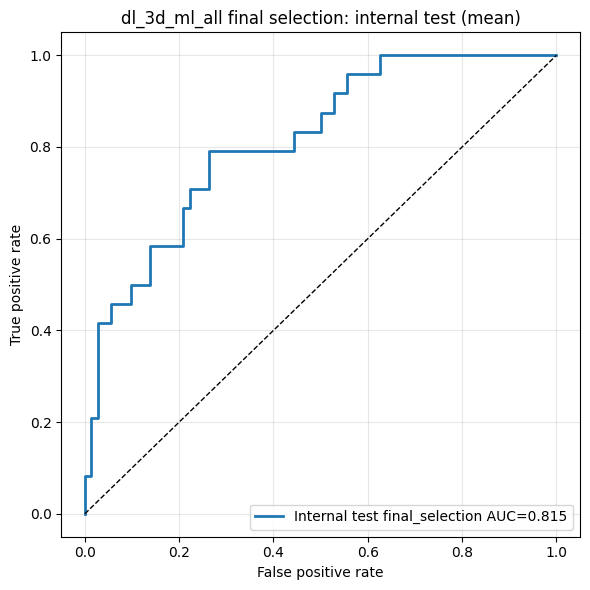

Saved ROC: /host/d/projects/Habitats/models/Prognosis/dl_3d_ml_all/final_selections/ROC_curve_internal_test_final_selection.pdf
Saved internal-test final-selection predictions: /host/d/projects/Habitats/models/Prognosis/dl_3d_ml_all/final_selections/internal_test_final_selection_predictions.xlsx
Saved internal-test final-selection metrics: /host/d/projects/Habitats/models/Prognosis/dl_3d_ml_all/final_selections/internal_test_final_selection_metrics.xlsx
Saved internal-test best mix: /host/d/projects/Habitats/models/Prognosis/dl_3d_ml_all/final_selections/internal_test_final_selection_best_mix.xlsx
Saved internal-test final-selection manifest: /host/d/projects/Habitats/models/Prognosis/dl_3d_ml_all/final_selections/internal_test_final_selection_manifest.json


,dataset,fusion_method,setting_tag,probability_column,input_probability_mode,is_final_selection,auc,auc_ci_low,auc_ci_high,threshold,accuracy,sensitivity,specificity,n,positive_fraction,final_selection_selected_method,source_probability_column
0,internal_test,single_setting,LR__random0_lasso_top6,prob_final_internal_test_LR__random0_lasso_top6,final,False,0.798032,0.698683,0.880639,0.345374,0.666667,0.916667,0.583333,96,0.25,NaN,NaN
1,internal_test,single_setting,XGBoost__random0_rfe_top10,prob_final_internal_test_XGBoost__random0_rfe_...,final,False,0.796875,0.687902,0.890111,0.725787,0.854167,0.500000,0.972222,96,0.25,NaN,NaN
2,internal_test,mean,selected_settings,prob_mean,NaN,True,0.815394,0.714091,0.901981,0.425834,0.750000,0.791667,0.736111,96,0.25,NaN,NaN
3,internal_test,mix,selected_settings,prob_mix,NaN,False,0.815394,0.714091,0.901981,0.425834,0.750000,0.791667,0.736111,96,0.25,NaN,NaN
4,internal_test,final_selection,selected_settings,prob_final_selection,NaN,True,0.815394,0.714091,0.901981,0.425834,0.750000,0.791667,0.736111,96,0.25,mean,prob_mean


,subset_size,selected_probability_columns,auc,combo_count
0,2,prob_final_internal_test_LR__random0_lasso_top...,0.815394,3


In [6]:
# ============================================================
# 6. Internal test final selection: selected settings -> mean, mix, and best final_selection
# ============================================================

internal_tables = []
internal_info = []

for item in selected_internal_test_experiments:
    table, info = read_holdout_prediction(
        item,
        dataset_name="internal_test",
        filename="internal_test_predictions.xlsx",
    )
    internal_tables.append(table)
    internal_info.append(info)
    print("Loaded internal test:", info["tag"], "probability column:", info["probability_column"])

internal_merged = merge_on_keys(internal_tables)
internal_prob_cols = [info["selected_probability_column"] for info in internal_info]
internal_merged["prob_mean"] = internal_merged[internal_prob_cols].mean(axis=1)
internal_merged["prob_mix"], internal_best_mix_df, internal_mix_combo_count = search_best_holdout_mix(
    internal_merged,
    prob_cols=internal_prob_cols, 
)
y_internal = internal_merged[LABEL_COL].astype(int).to_numpy()

internal_mean_auc = safe_auc(y_internal, internal_merged["prob_mean"].to_numpy())
internal_mix_auc = safe_auc(y_internal, internal_merged["prob_mix"].to_numpy())

if np.nan_to_num(internal_mix_auc, nan=-np.inf) > np.nan_to_num(internal_mean_auc, nan=-np.inf):
    internal_final_selection_method = "mix"
    internal_final_selection_source_col = "prob_mix"
else:
    internal_final_selection_method = "mean"
    internal_final_selection_source_col = "prob_mean"

internal_merged["prob_final_selection"] = internal_merged[internal_final_selection_source_col].astype(float)
internal_merged["final_selection_selected_method"] = internal_final_selection_method

print("Internal test mean AUC:", internal_mean_auc)
print("Internal test mix AUC :", internal_mix_auc)
print("Internal test final_selection selected method:", internal_final_selection_method)

internal_metric_rows = []
for info, prob_col in zip(internal_info, internal_prob_cols):
    row = {
        "dataset": "internal_test",
        "fusion_method": "single_setting",
        "setting_tag": info["tag"],
        "probability_column": prob_col,
        "input_probability_mode": info["probability_mode"],
        "is_final_selection": False,
    }
    row.update(evaluate_probability(y_internal, internal_merged[prob_col].to_numpy()))
    internal_metric_rows.append(row)

for method_name, prob_col in [("mean", "prob_mean"), ("mix", "prob_mix")]:
    row = {
        "dataset": "internal_test",
        "fusion_method": method_name,
        "setting_tag": "selected_settings",
        "probability_column": prob_col,
        "is_final_selection": method_name == internal_final_selection_method,
    }
    row.update(evaluate_probability(y_internal, internal_merged[prob_col].to_numpy()))
    internal_metric_rows.append(row)

row = {
    "dataset": "internal_test",
    "fusion_method": "final_selection",
    "final_selection_selected_method": internal_final_selection_method,
    "setting_tag": "selected_settings",
    "probability_column": "prob_final_selection",
    "source_probability_column": internal_final_selection_source_col,
    "is_final_selection": True,
}
row.update(evaluate_probability(y_internal, internal_merged["prob_final_selection"].to_numpy()))
internal_metric_rows.append(row)
internal_metrics_df = pd.DataFrame(internal_metric_rows)

internal_pred_path = os.path.join(final_selection_out_dir, "internal_test_final_selection_predictions.xlsx")
internal_metric_path = os.path.join(final_selection_out_dir, "internal_test_final_selection_metrics.xlsx")
internal_mix_path = os.path.join(final_selection_out_dir, "internal_test_final_selection_best_mix.xlsx")
internal_manifest_path = os.path.join(final_selection_out_dir, "internal_test_final_selection_manifest.json")
internal_roc_path = os.path.join(final_selection_out_dir, "ROC_curve_internal_test_final_selection.pdf")

internal_merged.to_excel(internal_pred_path, index=False)
internal_metrics_df.to_excel(internal_metric_path, index=False)
internal_best_mix_df.to_excel(internal_mix_path, index=False)
internal_manifest = {
    "task": TASK,
    "label_col": LABEL_COL,
    "image_type": IMAGE_TYPE,
    "selected_internal_test_experiments": selected_internal_test_experiments,
    "loaded_experiments": internal_info,
    "probability_columns": internal_prob_cols,
    "input_probability_mode": INTERNAL_TEST_PROBABILITY_MODE,
    "mean_auc": internal_mean_auc,
    "mix_auc": internal_mix_auc,
    "mix_combo_count": int(internal_mix_combo_count),
    "final_selection_selected_method": internal_final_selection_method,
    "final_selection_source_probability_column": internal_final_selection_source_col,
    "outputs": {
        "predictions": internal_pred_path,
        "metrics": internal_metric_path,
        "best_mix": internal_mix_path,
        "roc": internal_roc_path,
    },
}
with open(internal_manifest_path, "w") as f:
    json.dump(internal_manifest, f, indent=2)

plot_roc_curves(
    y_internal,
    [("Internal test final_selection", internal_merged["prob_final_selection"].to_numpy())],
    f"{DISPLAY_NAME} final selection: internal test ({internal_final_selection_method})",
    internal_roc_path,
)

print("Saved internal-test final-selection predictions:", internal_pred_path)
print("Saved internal-test final-selection metrics:", internal_metric_path)
print("Saved internal-test best mix:", internal_mix_path)
print("Saved internal-test final-selection manifest:", internal_manifest_path)
display(internal_metrics_df)
display(internal_best_mix_df)


Loaded external test: LR__random40_lasso_top6 probability column: prob_final
External test mean AUC: 0.7922403003754693
External test mix AUC : 0.7922403003754693
External test final_selection selected method: mean


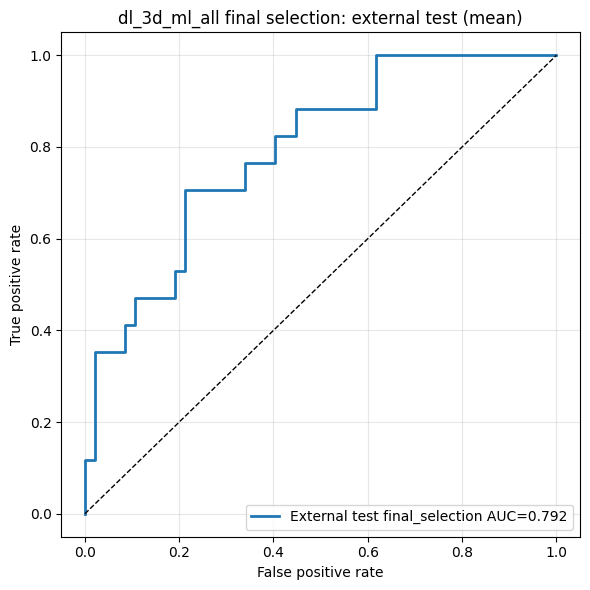

Saved ROC: /host/d/projects/Habitats/models/Prognosis/dl_3d_ml_all/final_selections/ROC_curve_external_test_final_selection.pdf
Saved external-test final-selection predictions: /host/d/projects/Habitats/models/Prognosis/dl_3d_ml_all/final_selections/external_test_final_selection_predictions.xlsx
Saved external-test final-selection metrics: /host/d/projects/Habitats/models/Prognosis/dl_3d_ml_all/final_selections/external_test_final_selection_metrics.xlsx
Saved external-test best mix: /host/d/projects/Habitats/models/Prognosis/dl_3d_ml_all/final_selections/external_test_final_selection_best_mix.xlsx
Saved external-test final-selection manifest: /host/d/projects/Habitats/models/Prognosis/dl_3d_ml_all/final_selections/external_test_final_selection_manifest.json


,dataset,fusion_method,setting_tag,probability_column,input_probability_mode,is_final_selection,auc,auc_ci_low,auc_ci_high,threshold,accuracy,sensitivity,specificity,n,positive_fraction,final_selection_selected_method,source_probability_column
0,external_test,single_setting,LR__random40_lasso_top6,prob_final_external_test_LR__random40_lasso_top6,final,False,0.79224,0.65731,0.903662,0.512995,0.765625,0.705882,0.787234,64,0.265625,NaN,NaN
1,external_test,mean,selected_settings,prob_mean,NaN,True,0.79224,0.65731,0.903662,0.512995,0.765625,0.705882,0.787234,64,0.265625,NaN,NaN
2,external_test,mix,selected_settings,prob_mix,NaN,False,0.79224,0.65731,0.903662,0.512995,0.765625,0.705882,0.787234,64,0.265625,NaN,NaN
3,external_test,final_selection,selected_settings,prob_final_selection,NaN,True,0.79224,0.65731,0.903662,0.512995,0.765625,0.705882,0.787234,64,0.265625,mean,prob_mean


,subset_size,selected_probability_columns,auc,combo_count
0,1,prob_final_external_test_LR__random40_lasso_top6,0.79224,1


In [7]:
# ============================================================
# 7. External test final selection: selected settings -> mean, mix, and best final_selection
# ============================================================

external_tables = []
external_info = []

for item in selected_external_test_experiments:
    table, info = read_holdout_prediction(
        item,
        dataset_name="external_test",
        filename="external_test_predictions.xlsx",
    )
    external_tables.append(table)
    external_info.append(info)
    print("Loaded external test:", info["tag"], "probability column:", info["probability_column"])

external_merged = merge_on_keys(external_tables)
external_prob_cols = [info["selected_probability_column"] for info in external_info]
external_merged["prob_mean"] = external_merged[external_prob_cols].mean(axis=1)
external_merged["prob_mix"], external_best_mix_df, external_mix_combo_count = search_best_holdout_mix(
    external_merged,
    prob_cols=external_prob_cols,
)
y_external = external_merged[LABEL_COL].astype(int).to_numpy()

external_mean_auc = safe_auc(y_external, external_merged["prob_mean"].to_numpy())
external_mix_auc = safe_auc(y_external, external_merged["prob_mix"].to_numpy())

if np.nan_to_num(external_mix_auc, nan=-np.inf) > np.nan_to_num(external_mean_auc, nan=-np.inf):
    external_final_selection_method = "mix"
    external_final_selection_source_col = "prob_mix"
else:
    external_final_selection_method = "mean"
    external_final_selection_source_col = "prob_mean"

external_merged["prob_final_selection"] = external_merged[external_final_selection_source_col].astype(float)
external_merged["final_selection_selected_method"] = external_final_selection_method

print("External test mean AUC:", external_mean_auc)
print("External test mix AUC :", external_mix_auc)
print("External test final_selection selected method:", external_final_selection_method)

external_metric_rows = []
for info, prob_col in zip(external_info, external_prob_cols):
    row = {
        "dataset": "external_test",
        "fusion_method": "single_setting",
        "setting_tag": info["tag"],
        "probability_column": prob_col,
        "input_probability_mode": info["probability_mode"],
        "is_final_selection": False,
    }
    row.update(evaluate_probability(y_external, external_merged[prob_col].to_numpy()))
    external_metric_rows.append(row)

for method_name, prob_col in [("mean", "prob_mean"), ("mix", "prob_mix")]:
    row = {
        "dataset": "external_test",
        "fusion_method": method_name,
        "setting_tag": "selected_settings",
        "probability_column": prob_col,
        "is_final_selection": method_name == external_final_selection_method,
    }
    row.update(evaluate_probability(y_external, external_merged[prob_col].to_numpy()))
    external_metric_rows.append(row)

row = {
    "dataset": "external_test",
    "fusion_method": "final_selection",
    "final_selection_selected_method": external_final_selection_method,
    "setting_tag": "selected_settings",
    "probability_column": "prob_final_selection",
    "source_probability_column": external_final_selection_source_col,
    "is_final_selection": True,
}
row.update(evaluate_probability(y_external, external_merged["prob_final_selection"].to_numpy()))
external_metric_rows.append(row)
external_metrics_df = pd.DataFrame(external_metric_rows)

external_pred_path = os.path.join(final_selection_out_dir, "external_test_final_selection_predictions.xlsx")
external_metric_path = os.path.join(final_selection_out_dir, "external_test_final_selection_metrics.xlsx")
external_mix_path = os.path.join(final_selection_out_dir, "external_test_final_selection_best_mix.xlsx")
external_manifest_path = os.path.join(final_selection_out_dir, "external_test_final_selection_manifest.json")
external_roc_path = os.path.join(final_selection_out_dir, "ROC_curve_external_test_final_selection.pdf")

external_merged.to_excel(external_pred_path, index=False)
external_metrics_df.to_excel(external_metric_path, index=False)
external_best_mix_df.to_excel(external_mix_path, index=False)
external_manifest = {
    "task": TASK,
    "label_col": LABEL_COL,
    "image_type": IMAGE_TYPE,
    "selected_external_test_experiments": selected_external_test_experiments,
    "loaded_experiments": external_info,
    "probability_columns": external_prob_cols,
    "input_probability_mode": EXTERNAL_TEST_PROBABILITY_MODE,
    "mean_auc": external_mean_auc,
    "mix_auc": external_mix_auc,
    "mix_combo_count": int(external_mix_combo_count),
    "final_selection_selected_method": external_final_selection_method,
    "final_selection_source_probability_column": external_final_selection_source_col,
    "outputs": {
        "predictions": external_pred_path,
        "metrics": external_metric_path,
        "best_mix": external_mix_path,
        "roc": external_roc_path,
    },
}
with open(external_manifest_path, "w") as f:
    json.dump(external_manifest, f, indent=2)

plot_roc_curves(
    y_external,
    [("External test final_selection", external_merged["prob_final_selection"].to_numpy())],
    f"{DISPLAY_NAME} final selection: external test ({external_final_selection_method})",
    external_roc_path,
)

print("Saved external-test final-selection predictions:", external_pred_path)
print("Saved external-test final-selection metrics:", external_metric_path)
print("Saved external-test best mix:", external_mix_path)
print("Saved external-test final-selection manifest:", external_manifest_path)
display(external_metrics_df)
display(external_best_mix_df)
